In [80]:
import dataiku
import pandas as pd

In [81]:
dataset = dataiku.Dataset('titanic')

In [82]:
df = dataset.get_dataframe()

In [83]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [84]:
df.size

10692

In [85]:
df #891 wierszy x 12 kolumn

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [86]:
df.columns #wyświetlamy kolumny

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'], dtype='object')

In [87]:
df.dtypes #wyświetlamy typy kolumn

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [88]:
df.isnull().sum() #wyświetlamy braki

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [89]:
## 3 - zbadaj dane

In [90]:
import matplotlib.pyplot as plt

In [91]:
df['Age'].max()

80.0

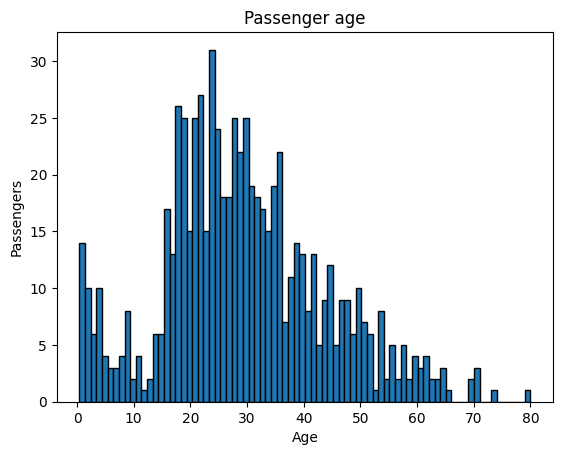

In [92]:
plt.hist(df['Age'].dropna(), bins=80, edgecolor = 'black')
plt.title('Passenger age')
plt.xlabel('Age')
plt.ylabel('Passengers')
plt.show()

In [93]:
df['Survived'].sum() # przeżyły 342 osoby

np.int64(342)

In [94]:
df['Survived'].mean() * 100 # ~38,38%

np.float64(38.38383838383838)

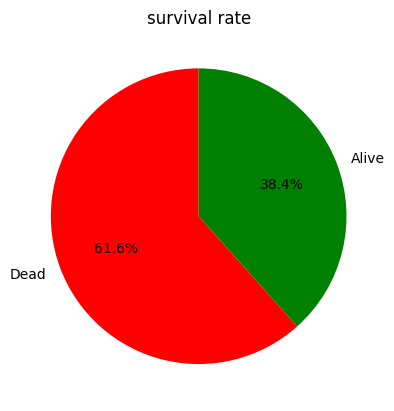

In [95]:
survived = df['Survived'].value_counts(normalize=True) * 100

plt.pie(
    survived,
    labels = ['Dead', 'Alive'],
    autopct = '%.1f%%',
    startangle=90,
    colors = ['red', 'green'])

plt.title('survival rate')

plt.show()

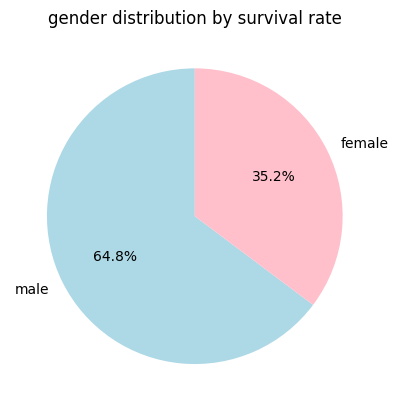

In [96]:
sex_counts = df['Sex'].value_counts()

plt.pie(
    sex_counts,
    labels = sex_counts.index,
    autopct = '%.1f%%',
    startangle=90,
    colors=['lightblue','pink'])

plt.title('gender distribution by survival rate')

plt.show()

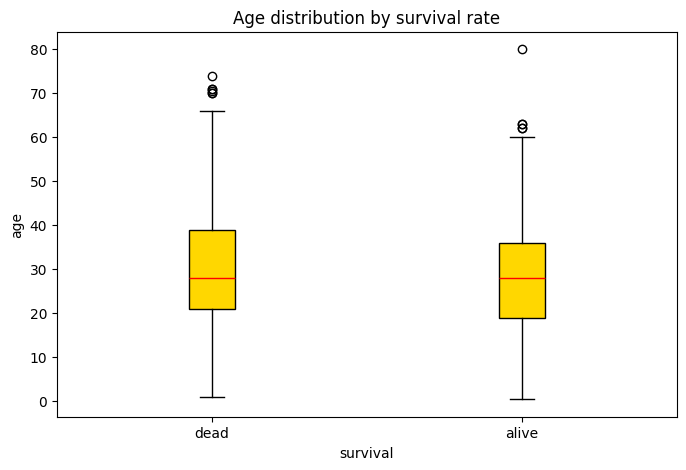

In [97]:
# boxplot 

dead = df[df['Survived'] == 0]['Age'].dropna()
alive = df[df['Survived'] == 1]['Age'].dropna()

plt.figure(figsize=(8,5))
plt.boxplot([dead, alive],
           tick_labels=['dead', 'alive'],
           patch_artist=True,
           boxprops=dict(facecolor='gold'),
           medianprops=dict(color='red'))

plt.title('Age distribution by survival rate')
plt.xlabel('survival')
plt.ylabel('age')
plt.show()